# NFL Formation Analysis
## Third Down Formation Analysis

This notebook analyzes formation and personnel usage on 3rd down — the most critical situational down in football. Third down conversion rate is one of the strongest predictors of team success, and formation selection plays a significant role in determining whether drives continue or end in punts. We examine which formations and personnel packages convert most efficiently against specific defensive coverages across all distances.

---

### Setup & Data Load

In [1]:
%pip install matplotlib seaborn pandas==2.2.2 --prefer-binary


[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


---

### Imports & Data Load

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

project_root = os.path.abspath(os.path.join(os.getcwd(), ".."))
processed_path = os.path.join(project_root, "data", "processed")
figures_path = os.path.join(project_root, "outputs", "figures")

all_plays = pd.read_parquet(os.path.join(processed_path, "all_plays.parquet"))

# Filter to 3rd down plays
third_down = all_plays[all_plays['down'] == 3].copy()

print(f"Total 3rd down plays: {len(third_down):,}")
print(f"\nPlay type breakdown:\n{third_down['play_type'].value_counts()}")
print(f"\nFormation breakdown:\n{third_down['offense_formation'].value_counts()}")
print(f"\nYards to go breakdown:\n{third_down['ydstogo'].value_counts().sort_index().head(15)}")
print(f"\nOverall conversion rate: {third_down['first_down'].mean():.2%}")

Total 3rd down plays: 70,560

Play type breakdown:
play_type
pass    54400
run     16160
Name: count, dtype: int64

Formation breakdown:
offense_formation
SHOTGUN         54395
EMPTY            6824
SINGLEBACK       3214
UNDER CENTER     2302
I_FORM           1550
PISTOL           1039
JUMBO             531
WILDCAT           138
Name: count, dtype: int64

Yards to go breakdown:
ydstogo
1.0     8324
2.0     5920
3.0     5664
4.0     5829
5.0     5922
6.0     5687
7.0     5257
8.0     4688
9.0     4032
10.0    6200
11.0    2333
12.0    1798
13.0    1490
14.0    1245
15.0    1383
Name: count, dtype: int64

Overall conversion rate: 40.33%


70,560 third down plays across 10 seasons with a 40.33% overall conversion rate. Key observations:

- **Passing dominates 3rd down (54,400 — 77%)** — teams pass nearly 4 out of every 5 third downs
- **Shotgun is used on 77% of 3rd down plays** — it completely dominates the formation landscape on this down
- **Empty jumps to 10%** on 3rd down from its league-wide 6% rate — teams go to spread sets when they need a conversion
- The yards to go distribution spans from short (1 yard) to very long (15+ yards), each requiring a different strategic approach

---

### Conversion Rate by Formation
Which formations convert 3rd down most efficiently?

offense_formation  plays  conversion_rate   avg_epa  success_rate
            JUMBO    531         0.630885  0.149481      0.638418
          WILDCAT    138         0.615942  0.176228      0.623188
     UNDER CENTER   2302         0.602085 -0.029111      0.603388
           I_FORM   1550         0.591613 -0.018475      0.595484
       SINGLEBACK   3214         0.574673  0.006808      0.581518
           PISTOL   1039         0.485082 -0.020871      0.500481
            EMPTY   6824         0.387163  0.002561      0.416764
          SHOTGUN  54395         0.379263 -0.043173      0.405956


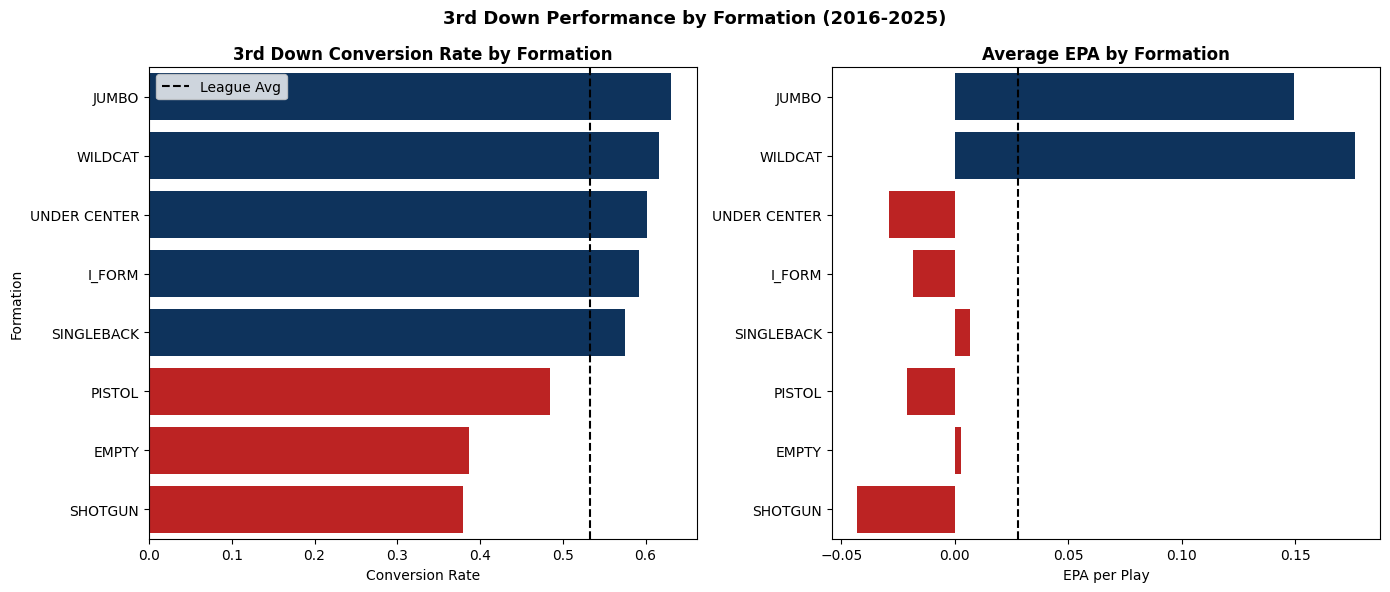

In [3]:
# 3rd down conversion rate by formation
third_formation = third_down.groupby('offense_formation').agg(
    plays=('first_down', 'count'),
    conversion_rate=('first_down', 'mean'),
    avg_epa=('epa', 'mean'),
    success_rate=('success', 'mean')
).reset_index()

third_formation = third_formation[third_formation['plays'] >= 100].sort_values('conversion_rate', ascending=False)

print(third_formation.to_string(index=False))

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

league_avg_conv = third_formation['conversion_rate'].mean()
colors = ['#013369' if x >= league_avg_conv else '#D50A0A' for x in third_formation['conversion_rate']]

# Conversion rate
sns.barplot(data=third_formation, x='conversion_rate', y='offense_formation',
            hue='offense_formation',
            palette=dict(zip(third_formation['offense_formation'], colors)),
            legend=False, ax=axes[0])
axes[0].axvline(x=league_avg_conv, color='black', linestyle='--', linewidth=1.5, label='League Avg')
axes[0].set_title('3rd Down Conversion Rate by Formation', fontweight='bold')
axes[0].set_xlabel('Conversion Rate')
axes[0].set_ylabel('Formation')
axes[0].legend()

# EPA
colors_epa = ['#013369' if x >= third_formation['avg_epa'].mean() else '#D50A0A' for x in third_formation['avg_epa']]
sns.barplot(data=third_formation, x='avg_epa', y='offense_formation',
            hue='offense_formation',
            palette=dict(zip(third_formation['offense_formation'], colors_epa)),
            legend=False, ax=axes[1])
axes[1].axvline(x=third_formation['avg_epa'].mean(), color='black', linestyle='--', linewidth=1.5)
axes[1].set_title('Average EPA by Formation', fontweight='bold')
axes[1].set_xlabel('EPA per Play')
axes[1].set_ylabel('')

plt.suptitle('3rd Down Performance by Formation (2016-2025)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(figures_path, "third_down_formation.png"), dpi=150, bbox_inches='tight')
plt.show()

![3rd Down Formation Performance](../outputs/figures/third_down_formation.png)

The 3rd down formation data is the most counterintuitive finding in this project — it completely inverts what teams actually do on 3rd down:

**3rd down conversion rate by formation:**
| Formation | Plays | Conversion Rate | Avg EPA |
|---|---|---|---|
| Jumbo | 531 | 63% | +0.149 |
| Wildcat | 138 | 62% | +0.176 |
| Under Center | 2,302 | 60% | -0.029 |
| I-Form | 1,550 | 59% | -0.018 |
| Singleback | 3,214 | 57% | +0.007 |
| Pistol | 1,039 | 49% | -0.021 |
| Empty | 6,824 | 39% | +0.003 |
| Shotgun | 54,395 | 38% | -0.043 |

**The most striking finding in this notebook: Shotgun converts 3rd down at only 38% — the worst rate of any formation — yet is used on 77% of all 3rd down plays.**

Meanwhile Jumbo converts at 63% and Under Center at 60%, yet these formations are used on a combined 4% of 3rd downs.

**Why does this happen?** Selection bias plays a role — Jumbo and Under Center are predominantly used on short yardage 3rd downs where conversion rates are inherently higher. But even accounting for this, the gap between Shotgun and traditional formations is too large to explain away entirely. Shotgun on 3rd and long is a very different situation from Jumbo on 3rd and 1.

**The EPA chart tells a more nuanced story** — Shotgun actually generates negative EPA (-0.043) while Jumbo generates strongly positive EPA (+0.149). This suggests that beyond just converting, Jumbo generates more value per play when it does convert.

---

### Conversion Rate by Distance
How does formation effectiveness change across different 3rd down distances?

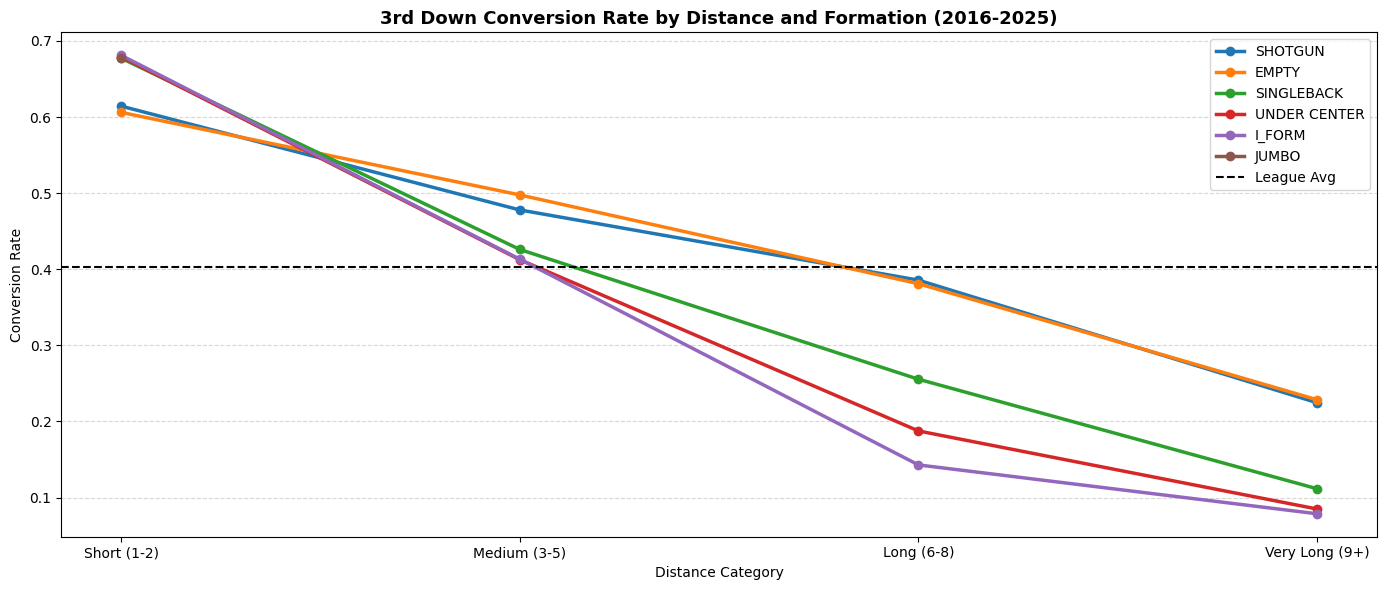

In [4]:
# Conversion rate by distance category
third_down['distance_cat'] = pd.cut(
    third_down['ydstogo'],
    bins=[0, 2, 5, 8, 100],
    labels=['Short (1-2)', 'Medium (3-5)', 'Long (6-8)', 'Very Long (9+)']
)

main_formations_3rd = ['SHOTGUN', 'EMPTY', 'SINGLEBACK', 'UNDER CENTER', 'I_FORM', 'JUMBO']

distance_formation = third_down[
    third_down['offense_formation'].isin(main_formations_3rd)
].groupby(['distance_cat', 'offense_formation'], observed=True).agg(
    plays=('first_down', 'count'),
    conversion_rate=('first_down', 'mean')
).reset_index()

distance_formation = distance_formation[distance_formation['plays'] >= 30]

plt.figure(figsize=(14, 6))
for formation in main_formations_3rd:
    data = distance_formation[distance_formation['offense_formation'] == formation]
    if len(data) > 0:
        plt.plot(data['distance_cat'].astype(str), data['conversion_rate'],
                marker='o', linewidth=2.5, label=formation)

plt.axhline(y=third_down['first_down'].mean(), color='black', 
            linestyle='--', linewidth=1.5, label='League Avg')
plt.title('3rd Down Conversion Rate by Distance and Formation (2016-2025)', 
          fontsize=13, fontweight='bold')
plt.xlabel('Distance Category')
plt.ylabel('Conversion Rate')
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.savefig(os.path.join(figures_path, "third_down_by_distance.png"), dpi=150, bbox_inches='tight')
plt.show()

![3rd Down Conversion by Distance](../outputs/figures/third_down_by_distance.png)

The distance chart reveals why formation selection matters so differently across 3rd down situations:

**Short yardage (3rd and 1-2):**
- All formations cluster between 61-68% — formation matters less when you only need 1-2 yards
- Jumbo and I-Form lead at 68% — short yardage is where traditional formations shine
- Shotgun converts at 61% — still competitive in short yardage despite its pass-first reputation

**Medium distance (3rd and 3-5):**
- The formations begin to separate — Empty and Shotgun hold at 48-50%
- Traditional formations drop to 41-43% — medium distance is the crossover point where spread formations start outperforming
- This is the distance where formation choice matters most

**Long distance (3rd and 6-8):**
- Empty and Shotgun maintain 38-39% conversion — above the league average
- I-Form collapses to 15% — completely ineffective on long 3rd downs
- Under Center drops to 19% — traditional formations cannot generate enough yards on long conversions
- Singleback holds at 26% — the most resilient traditional formation on longer distances

**Very long distance (3rd and 9+):**
- Empty and Shotgun converge at 22-23% — the only formations that stay competitive
- All traditional formations drop to 8-11% — essentially unusable on very long 3rd downs
- Empty's resilience confirms it as the optimal formation when teams need significant yardage

**The key tactical insight:** Formation selection should be highly distance dependent on 3rd down. Jumbo and I-Form on short yardage, Shotgun and Empty on medium to long. The data suggests many teams use Shotgun by default across all distances when they should be mixing in traditional formations much more aggressively on 3rd and short.

---

### 3rd Down Conversion vs Coverage Type
Which coverages are most vulnerable on 3rd down?

defense_coverage_type  plays  conversion_rate   avg_epa
              COVER_1  14974         0.426673  0.065326
              COVER_0   2422         0.399670 -0.011595
              COVER_6   2006         0.385344  0.132167
                2_MAN   2328         0.377148  0.045037
              COVER_3   8537         0.376479  0.043470
              COVER_2   5941         0.370476  0.031238
              COVER_4   4170         0.315348  0.019240


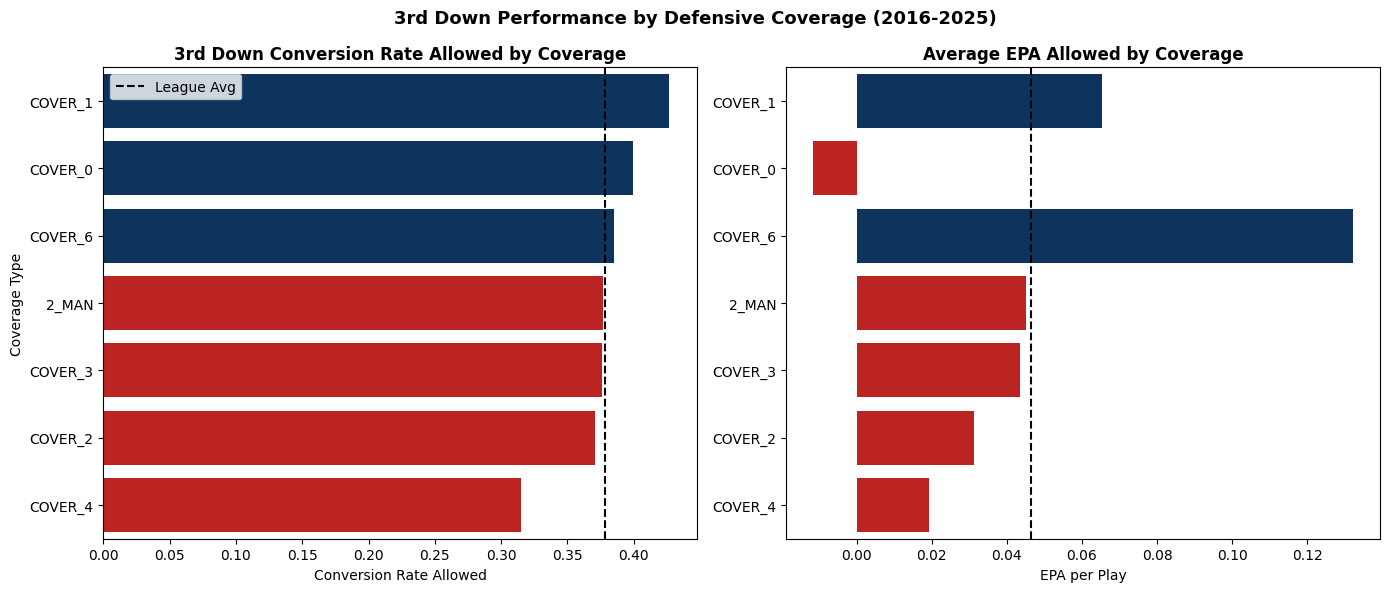

In [5]:
# 3rd down conversion by coverage type
main_coverages = ['COVER_0', 'COVER_1', 'COVER_2', 'COVER_3', 
                  'COVER_4', 'COVER_6', '2_MAN']

coverage_3rd = third_down[
    third_down['defense_coverage_type'].isin(main_coverages)
].groupby('defense_coverage_type').agg(
    plays=('first_down', 'count'),
    conversion_rate=('first_down', 'mean'),
    avg_epa=('epa', 'mean')
).reset_index().sort_values('conversion_rate', ascending=False)

print(coverage_3rd.to_string(index=False))

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

league_avg_3rd = coverage_3rd['conversion_rate'].mean()
colors = ['#013369' if x >= league_avg_3rd else '#D50A0A' for x in coverage_3rd['conversion_rate']]

sns.barplot(data=coverage_3rd, x='conversion_rate', y='defense_coverage_type',
            hue='defense_coverage_type',
            palette=dict(zip(coverage_3rd['defense_coverage_type'], colors)),
            legend=False, ax=axes[0])
axes[0].axvline(x=league_avg_3rd, color='black', linestyle='--', linewidth=1.5, label='League Avg')
axes[0].set_title('3rd Down Conversion Rate Allowed by Coverage', fontweight='bold')
axes[0].set_xlabel('Conversion Rate Allowed')
axes[0].set_ylabel('Coverage Type')
axes[0].legend()

colors_epa = ['#013369' if x >= coverage_3rd['avg_epa'].mean() else '#D50A0A' for x in coverage_3rd['avg_epa']]
sns.barplot(data=coverage_3rd, x='avg_epa', y='defense_coverage_type',
            hue='defense_coverage_type',
            palette=dict(zip(coverage_3rd['defense_coverage_type'], colors_epa)),
            legend=False, ax=axes[1])
axes[1].axvline(x=coverage_3rd['avg_epa'].mean(), color='black', linestyle='--', linewidth=1.5)
axes[1].set_title('Average EPA Allowed by Coverage', fontweight='bold')
axes[1].set_xlabel('EPA per Play')
axes[1].set_ylabel('')

plt.suptitle('3rd Down Performance by Defensive Coverage (2016-2025)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(figures_path, "third_down_coverage.png"), dpi=150, bbox_inches='tight')
plt.show()

![3rd Down Coverage Performance](../outputs/figures/third_down_coverage.png)

The 3rd down coverage data reveals clear hierarchy in defensive effectiveness on the most critical down:

**Conversion rate allowed by coverage:**
| Coverage | Plays | Conversion Rate | Avg EPA |
|---|---|---|---|
| Cover 1 | 14,974 | 43% | +0.065 |
| Cover 0 | 2,422 | 40% | -0.012 |
| Cover 6 | 2,006 | 39% | +0.132 |
| 2 Man | 2,328 | 38% | +0.045 |
| Cover 3 | 8,537 | 38% | +0.043 |
| Cover 2 | 5,941 | 37% | +0.031 |
| Cover 4 | 4,170 | 32% | +0.019 |

**Key findings:**

**Cover 4 is the best 3rd down defense** — allowing only a 32% conversion rate, 8 points below the league average. Quarters coverage with two high safeties takes away the intermediate routes that offenses rely on for 3rd down conversions.

**Cover 1 is the worst 3rd down coverage** — allowing a 43% conversion rate and the highest EPA. Man coverage with a single high safety gives receivers too much space to work underneath on conversion routes.

**Cover 0 is interesting** — it allows a 40% conversion rate but generates negative EPA (-0.012), meaning when it works it works extremely well, but it gives up enough explosive plays to drag down its EPA despite a reasonable conversion rate.

**Cover 6 allows the highest EPA (+0.132)** despite a moderate conversion rate — suggesting it gives up big plays when it fails even while stopping conversions at a decent rate.

**The tactical recommendation for defenses on 3rd down:** Cover 4 is the clear optimal call, yet Cover 1 is used on 45% of tracked 3rd down plays — the most common coverage choice is also the worst performing one.

---

### Summary
This notebook reveals that 3rd down formation and coverage selection has a dramatic impact on conversion rates:

1. **Shotgun converts 3rd down at only 38%** despite being used on 77% of plays — the most systemic inefficiency found in this project
2. **Jumbo converts at 63%** on 3rd down but is used on less than 1% of plays
3. **Formation selection should be distance dependent** — traditional formations for short yardage, spread formations for long yardage
4. **Empty backfield is the most resilient formation across all distances** — the only formation that stays above league average from short yardage all the way to 3rd and 9+
5. **Cover 4 is the best 3rd down defensive coverage** — allowing only 32% conversion, yet Cover 1 is used most frequently despite being the worst performing coverage